<a href="https://colab.research.google.com/github/BelindaAmoako/spotify-top50-2020-eda/blob/main/Spotify_Top_50_%E2%80%94_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Top 50 Spotify Tracks 2020 dataset - Content Analsyis**

**Aim**

I'll be analsying the 50 most-streamed Spotify tracks of 2020 to understand what characterises a hit song. Working from a dataset of audio features supplied by a colleague, I set out to answer a list of questions from our product manager covering the artists, albums and genres represented in the chart, how the audio features relate to one another, and how the main genres differ.

**Approach**

Load and clean the data, then work through the questions in three blocks: descriptive (who and what is in the chart), relational (how the audio features correlate), and comparative (how genres differ on danceability, loudness and acousticness). Each section states what I'm testing, what I found, and what it means.

**Headline findings**


*   The chart is concentrated, not diverse — 7 artists account for 14 of the 50 tracks, and 4 albums account for 9.
* Hits cluster tightly on danceability: 32 of 50 score above 0.7, and only one falls below 0.4.

**Key limitation**

This dataset contains only hits. Without a comparison group of non-charting tracks, I can describe what hit songs sounded like in 2020, but I can't establish what made them hits. My recommendations at the end set out how to close that gap.

In [72]:
import pandas as pd

FILE_ID = '1OCLBg3oI9nmoB4BKaGRgcN0-yM6B5pr6'
url = f'https://drive.google.com/uc?id={FILE_ID}'

df = pd.read_csv(url)

In [73]:
df.isna().sum()

,0
Unnamed: 0,0
artist,0
album,0
track_name,0
track_id,0
energy,0
danceability,0
key,0
loudness,0
acousticness,0


In [74]:
df.duplicated().sum()                                    # 0
df.duplicated(subset=['track_name', 'artist']).sum()     # 0

np.int64(0)

In [75]:

### Q.1 How many observations are there in this dataset?
### Q.2 How many features does this dataset have?
### Q.3 Which of the features are categorical?
### Q.4 Which of the features are numeric?

df.shape
df.info()
df.dtypes
df.describe()     # numeric summary
df.describe(include='object')   # categorical summary
df.nunique()      # this one earns its keep — see below

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        50 non-null     int64  
 1   artist            50 non-null     object 
 2   album             50 non-null     object 
 3   track_name        50 non-null     object 
 4   track_id          50 non-null     object 
 5   energy            50 non-null     float64
 6   danceability      50 non-null     float64
 7   key               50 non-null     int64  
 8   loudness          50 non-null     float64
 9   acousticness      50 non-null     float64
 10  speechiness       50 non-null     float64
 11  instrumentalness  50 non-null     float64
 12  liveness          50 non-null     float64
 13  valence           50 non-null     float64
 14  tempo             50 non-null     float64
 15  duration_ms       50 non-null     int64  
 16  genre             50 non-null     object 
dtyp

,0
Unnamed: 0,50
artist,40
album,45
track_name,50
track_id,50
energy,49
danceability,48
key,12
loudness,50
acousticness,49


In [76]:
#Q.5 Are there any artists that have more than 1 popular track? If yes, which and how many?

artist_counts = df['artist'].value_counts()
artist_counts[artist_counts > 1]

,count
artist,
Dua Lipa,3
Billie Eilish,3
Travis Scott,3
Harry Styles,2
Lewis Capaldi,2
Justin Bieber,2
Post Malone,2


In [77]:
#6. Who was the most popular artist?

artist_counts[artist_counts == artist_counts.max()]


,count
artist,
Dua Lipa,3
Billie Eilish,3
Travis Scott,3


In [78]:
#. How many artists in total?

df['artist'].nunique()

40

In [79]:
df.groupby('album')['artist'].nunique().max()   # returns 1 → no collisions

1

In [80]:
#Q8 — "Are there any albums that have more than 1 popular track? If yes, which and how many?"

album_counts = df.groupby(['artist', 'album']).size().sort_values(ascending=False)
album_counts[album_counts > 1]

,,0
artist,album,
Dua Lipa,Future Nostalgia,3
Post Malone,Hollywood's Bleeding,2
Justin Bieber,Changes,2
Harry Styles,Fine Line,2


In [81]:
#Q.9 How many albums in total have their songs in the top 50?

df['album'].nunique()

45

In [82]:
print(f"Total albums represented in the top 50: {df['album'].nunique()}")

Total albums represented in the top 50: 45


In [83]:
### Q.10 Which tracks have a danceability score above 0.7?
high_dance = df.loc[df['danceability'] > 0.7, cols].sort_values('danceability', ascending=False)
print(f'{len(high_dance)} tracks')
high_dance

32 tracks


,track_name,artist,danceability,loudness
27,WAP (feat. Megan Thee Stallion),Cardi B,0.935,-7.509
2,The Box,Roddy Ricch,0.896,-6.687
39,Ride It,Regard,0.880,-4.258
28,Sunday Best,Surfaces,0.878,-6.832
33,Supalonely (feat. Gus Dapperton),BENEE,0.862,-4.746
40,goosebumps,Travis Scott,0.841,-3.370
49,SICKO MODE,Travis Scott,0.834,-3.714
15,Toosie Slide,Drake,0.830,-8.820
1,Dance Monkey,Tones And I,0.825,-6.401
29,Godzilla (feat. Juice WRLD),Eminem,0.808,-5.260


In [84]:
### Q11 — Danceability below 0.4
low_dance = df.loc[df['danceability'] < 0.4, cols]
print(f'{len(low_dance)} tracks')
low_dance

1 tracks


,track_name,artist,danceability,loudness
44,lovely (with Khalid),Billie Eilish,0.351,-10.109


In [85]:
### Q12 — Loudness above -5
loud = df.loc[df['loudness'] > -5, cols].sort_values('loudness', ascending=False)
print(f'{len(loud)} tracks')
loud

19 tracks


,track_name,artist,danceability,loudness
10,Tusa,KAROL G,0.803,-3.280
40,goosebumps,Travis Scott,0.841,-3.370
31,Break My Heart,Dua Lipa,0.730,-3.434
38,Hawái,Maluma,0.783,-3.454
12,Circles,Post Malone,0.695,-3.497
23,Mood (feat. iann dior),24kGoldn,0.700,-3.558
21,Adore You,Harry Styles,0.676,-3.675
49,SICKO MODE,Travis Scott,0.834,-3.714
48,Physical,Dua Lipa,0.647,-3.756
35,Rain On Me (with Ariana Grande),Lady Gaga,0.672,-3.764


In [86]:
## Q13 — Loudness below -8
quiet = df.loc[df['loudness'] < -8, cols].sort_values('loudness')
print(f'{len(quiet)} tracks')
quiet

9 tracks


,track_name,artist,danceability,loudness
24,everything i wanted,Billie Eilish,0.704,-14.454
26,bad guy,Billie Eilish,0.701,-10.965
44,lovely (with Khalid),Billie Eilish,0.351,-10.109
47,If the World Was Ending - feat. Julia Michaels,JP Saxe,0.464,-10.086
15,Toosie Slide,Drake,0.830,-8.820
7,death bed (coffee for your head),Powfu,0.726,-8.765
36,HIGHEST IN THE ROOM,Travis Scott,0.598,-8.764
8,Falling,Trevor Daniel,0.784,-8.756
20,Savage Love (Laxed - Siren Beat),Jawsh 685,0.767,-8.520


In [87]:
### Q.14 Which track is the longest?

df.loc[df['duration_ms'].idxmax(), ['track_name', 'artist', 'duration_ms']]

,49
track_name,SICKO MODE
artist,Travis Scott
duration_ms,312820


In [88]:
### Q.15 Which track is the shortest?
df.loc[df['duration_ms'].idxmin(), ['track_name', 'artist', 'duration_ms']]

,23
track_name,Mood (feat. iann dior)
artist,24kGoldn
duration_ms,140526


In [89]:
### Q.16 Which genre is the most popular?
genre_counts = df['genre'].value_counts()
genre_counts.head()

,count
genre,
Pop,14
Hip-Hop/Rap,13
Dance/Electronic,5
Alternative/Indie,4
R&B/Soul,2


In [90]:
### Q.17 Which genres have just one song in the top 50?
genre_counts[genre_counts == 1]

,count
genre,
R&B/Hip-Hop alternative,1
Nu-disco,1
Pop/Soft Rock,1
Pop rap,1
Hip-Hop/Trap,1
Dance-pop/Disco,1
Disco-pop,1
Dreampop/Hip-Hop/R&B,1
Alternative/reggaeton/experimental,1


In [91]:
### Q.18. How many genres in total are represented in the top 50?
print(f"Total genres represented: {len(genre_counts)}")  #len(genre_counts)

Total genres represented: 16


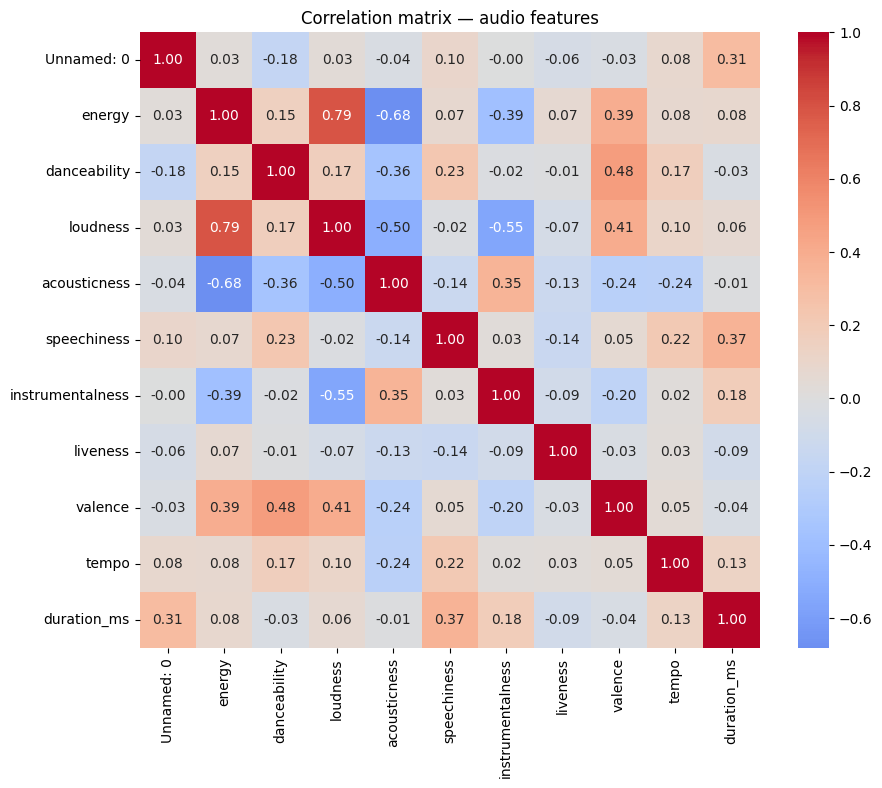

In [92]:
### Q.19/20/21 Correlations Which features are strongly positively/negatively correlated?

numeric = [c for c in df.select_dtypes('number').columns if c != 'key']
corr = df[numeric].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — audio features')
plt.show()

In [93]:
### Q.22 - How does the danceability score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?

main_genres = ['Pop', 'Hip-Hop/Rap', 'Dance/Electronic', 'Alternative/Indie']
subset = df[df['genre'].isin(main_genres)]

subset.groupby('genre')['danceability'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)

,count,mean,median,std,min,max
genre,,,,,,
Alternative/Indie,4,0.662,0.663,0.211,0.459,0.862
Dance/Electronic,5,0.755,0.785,0.095,0.647,0.880
Hip-Hop/Rap,13,0.766,0.774,0.085,0.598,0.896
Pop,14,0.678,0.690,0.110,0.464,0.806


In [94]:
### Q.23 How does the loudness score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?

subset.groupby('genre')['loudness'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)


,count,mean,median,std,min,max
genre,,,,,,
Alternative/Indie,4,-5.421,-5.268,0.775,-6.401,-4.746
Dance/Electronic,5,-5.338,-5.457,1.479,-7.567,-3.756
Hip-Hop/Rap,13,-6.918,-7.648,1.892,-8.820,-3.370
Pop,14,-6.460,-6.644,3.014,-14.454,-3.280


In [95]:
### Q.24 How does the acoustics score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?

subset.groupby('genre')['acousticness'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)

,count,mean,median,std,min,max
genre,,,,,,
Alternative/Indie,4,0.584,0.646,0.204,0.291,0.751
Dance/Electronic,5,0.099,0.069,0.096,0.014,0.223
Hip-Hop/Rap,13,0.189,0.145,0.186,0.005,0.731
Pop,14,0.324,0.259,0.318,0.021,0.902
